In [274]:
import warnings
warnings.filterwarnings('ignore')

# Kaggle Competition link - [Click Here](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)

# Loading Required Libraries

In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### Loading Dataset

In [276]:
house = pd.read_csv('train.csv')
house_test = pd.read_csv('test.csv')

In [277]:
house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [278]:
# house_test.info()
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Data has 1460 rows and 81 columns.
### **3** columns are float, **35** are int, and **43** columns, which is more than half are of object dtype.

In [279]:
house.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [280]:
house.count().sort_values()[:10] # columns with most null values.

PoolQC             7
MiscFeature       54
Alley             91
Fence            281
MasVnrType       588
FireplaceQu      770
LotFrontage     1201
GarageType      1379
GarageCond      1379
GarageFinish    1379
dtype: int64

### The columns:
### *'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'* 
### have more than half null values. So I'm dropping them right now.

In [281]:
house.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'MasVnrArea'], inplace=True)
house_test.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'MasVnrArea'], inplace=True)

(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.]),
 [Text(-10.0, 0, '2ndFlrSF'),
  Text(0.0, 0, 'Street'),
  Text(10.0, 0, 'KitchenAbvGr'),
  Text(20.0, 0, 'GarageCars'),
  Text(30.0, 0, 'RoofStyle'),
  Text(40.0, 0, 'RoofMatl'),
  Text(50.0, 0, 'Exterior2nd'),
  Text(60.0, 0, 'EnclosedPorch'),
  Text(70.0, 0, 'BsmtUnfSF'),
  Text(80.0, 0, '')])

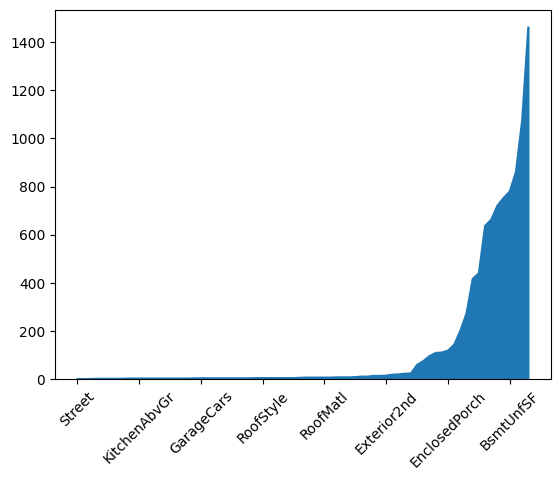

In [282]:
house.nunique().sort_values().plot(kind='area')
plt.xticks(rotation=45)

### Many columns are categorical type. They don't have a lot of unique values. They provide information about a feature of house. Like the columns *street* tells the type of road access to the property, which is either gravel or paved.

### Let's see which columns still have nan values.

In [283]:
count_of_non_null_values = house.count()
count_of_non_null_values[count_of_non_null_values<1460]

LotFrontage     1201
BsmtQual        1423
BsmtCond        1423
BsmtExposure    1422
BsmtFinType1    1423
BsmtFinType2    1422
Electrical      1459
GarageType      1379
GarageYrBlt     1379
GarageFinish    1379
GarageQual      1379
GarageCond      1379
dtype: int64

In [284]:
count_of_non_null_values = house_test.count()
count_of_non_null_values[count_of_non_null_values<1459]

MSZoning        1455
LotFrontage     1232
Utilities       1457
Exterior1st     1458
Exterior2nd     1458
BsmtQual        1415
BsmtCond        1414
BsmtExposure    1415
BsmtFinType1    1417
BsmtFinSF1      1458
BsmtFinType2    1417
BsmtFinSF2      1458
BsmtUnfSF       1458
TotalBsmtSF     1458
BsmtFullBath    1457
BsmtHalfBath    1457
KitchenQual     1458
Functional      1457
GarageType      1383
GarageYrBlt     1381
GarageFinish    1381
GarageCars      1458
GarageArea      1458
GarageQual      1381
GarageCond      1381
SaleType        1458
dtype: int64

In [285]:
house[['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual']] = house[['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual']].fillna('NoBasement')
house_test[['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual']] = house_test[['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual']].fillna('NoBasement')

### Setting the null values of these columns to No basement. Because these cell give info about basement of house, and null values mean house does not have a basement.

In [286]:
house[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']] = house[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']].fillna('NoGarage')
house_test[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']] = house_test[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']].fillna('NoGarage')

### Setting null values of these columns to No Garage for the same reason

In [287]:
house['Electrical'] = house['Electrical'].fillna('SBrkr')
house_test['Electrical'] = house_test['Electrical'].fillna('SBrkr')

### Filling the one missing value for this column with most common value

### The LotFrontage is the linear feet of the property connnected to street. A lot this has missing values. There maybe a chance that that property does not has any side connected to a street but that is very rare for so many properties. So instead of setting the nan values to zero I set them to the median value for their neighborhood. 

In [288]:
house['LotFrontage'] = house.groupby('Neighborhood')['LotFrontage'].transform(lambda x : x.fillna(x.median()))
house_test['LotFrontage'] = house_test.groupby('Neighborhood')['LotFrontage'].transform(lambda x : x.fillna(x.median()))

### The column GarageYrBlt show the year in which the garage was built. So setting it nan values to zero would be a good idea, a model may interpret that it's a very old garage. Also setting it to "No Garage" will also mix the dtype of the column since years are integers.

### So I'm adding a new column that tells if a house has a garage or not. And the fill nan value of year to 0.

In [289]:
house['HasGarage'] = house['GarageYrBlt'].notna().astype(int)
house_test['HasGarage'] = house_test['GarageYrBlt'].notna().astype(int)

In [290]:
house['GarageYrBlt'] = house['GarageYrBlt'].fillna(0)
house_test['GarageYrBlt'] = house_test['GarageYrBlt'].fillna(0)

In [291]:
count_of_non_null_values = house_test.count()
count_of_non_null_values[count_of_non_null_values<1459]

MSZoning        1455
Utilities       1457
Exterior1st     1458
Exterior2nd     1458
BsmtFinSF1      1458
BsmtFinSF2      1458
BsmtUnfSF       1458
TotalBsmtSF     1458
BsmtFullBath    1457
BsmtHalfBath    1457
KitchenQual     1458
Functional      1457
GarageCars      1458
GarageArea      1458
SaleType        1458
dtype: int64

### Test set  still has some of the nan values in some columns.

### Filling these values with median and mode values of respective column

In [292]:
house_test['MSZoning'] = house_test['MSZoning'].fillna(house_test['MSZoning'].mode()[0])
house_test['Exterior1st'] = house_test['Exterior1st'].fillna(house_test['Exterior1st'].mode()[0])
house_test['Exterior2nd'] = house_test['Exterior2nd'].fillna(house_test['Exterior2nd'].mode()[0])
house_test['BsmtFinSF1'] = house_test['BsmtFinSF1'].fillna(house_test['BsmtFinSF1'].median())
house_test['BsmtFinSF2'] = house_test['BsmtFinSF2'].fillna(house_test['BsmtFinSF2'].median())
house_test['BsmtUnfSF'] = house_test['BsmtUnfSF'].fillna(house_test['BsmtUnfSF'].median())
house_test['TotalBsmtSF'] = house_test['TotalBsmtSF'].fillna(house_test['TotalBsmtSF'].median())
house_test['TotalBsmtSF'] = house_test['TotalBsmtSF'].fillna(house_test['TotalBsmtSF'].median())
house_test['BsmtFullBath'] = house_test['BsmtFullBath'].fillna(house_test['BsmtFullBath'].mode()[0])
house_test['BsmtHalfBath'] = house_test['BsmtHalfBath'].fillna(house_test['BsmtHalfBath'].mode()[0])
house_test['KitchenQual'] = house_test['KitchenQual'].fillna(house_test['KitchenQual'].mode()[0])
house_test['Functional'] = house_test['Functional'].fillna(house_test['Functional'].mode()[0])
house_test['GarageCars'] = house_test['GarageCars'].fillna(house_test['GarageCars'].mode()[0])
house_test['GarageArea'] = house_test['GarageArea'].fillna(house_test['GarageArea'].median())
house_test['SaleType'] = house_test['SaleType'].fillna(house_test['SaleType'].mode()[0])


### Now we don't have any nan values in the dataset

In [293]:
for cols in house.columns:
    s = house[cols].value_counts()
    if len(s) <= 2:
        print(s)
        print('\n')

Street
Pave    1454
Grvl       6
Name: count, dtype: int64


Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64


CentralAir
Y    1365
N      95
Name: count, dtype: int64


HasGarage
1    1379
0      81
Name: count, dtype: int64




### The columns street and Utilities have same value for most of the house. Dropping them from the dataset

In [294]:
house.drop(columns=['Utilities', 'Street'], inplace=True)
house_test.drop(columns=['Utilities', 'Street'], inplace=True)

# Adding some features: 
1. Total Area of house = Basement area + first floor area + second floor area
2. House Age = Built Year of the House - Sale Year of the House
3. Remodelling Date = Built Year of the House - Remodelling  Year of the House

In [295]:
house['TotalSF'] = house['TotalBsmtSF'] + house['1stFlrSF'] + house['2ndFlrSF']
house['HouseAge'] = house['YrSold'] - house['YearBuilt']
house['RemodelAge'] = house['YearRemodAdd'] - house['YearBuilt']
house[['TotalSF', 'HouseAge', 'RemodelAge']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   TotalSF     1460 non-null   int64
 1   HouseAge    1460 non-null   int64
 2   RemodelAge  1460 non-null   int64
dtypes: int64(3)
memory usage: 34.3 KB


### Also adding them in the test set.

In [296]:
house_test['TotalSF'] = house_test['TotalBsmtSF'] + house_test['1stFlrSF'] + house_test['2ndFlrSF']
house_test['HouseAge'] = house_test['YrSold'] - house_test['YearBuilt']
house_test['RemodelAge'] = house_test['YearRemodAdd'] - house_test['YearBuilt']
house_test[['TotalSF', 'HouseAge', 'RemodelAge']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TotalSF     1459 non-null   float64
 1   HouseAge    1459 non-null   int64  
 2   RemodelAge  1459 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 34.3 KB


# Defining X and y.

<Axes: ylabel='Density'>

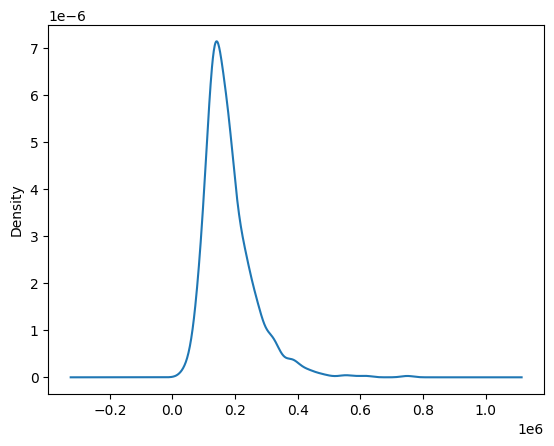

In [297]:
y = house['SalePrice']
y.plot(kind='density')

### The price column in skewed to the right. Taking the log to reduce skewness.

<Axes: ylabel='Density'>

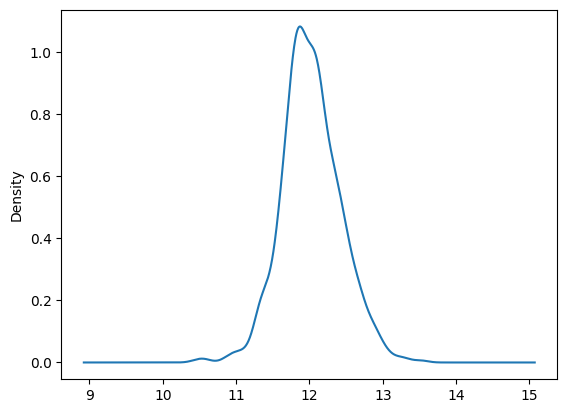

In [298]:
y = np.log1p(house['SalePrice']) # we used log(1+x) instead of log for safety because log(0) gives -inf for x=0.
y.plot(kind='density')

### Skewness is now balanced.

In [299]:
X = house.drop(columns=['Id', 'SalePrice']) # Dropping the Id column because it's just a identifier for a house and does not provide any insight on a house's price.
X_test = house_test.drop(columns=['Id'])
submission_ids = house_test['Id']

### Let's segregate numeric and categorical columns.

In [300]:
numeric_cols = X.select_dtypes(include='number').columns.to_list()
categorical_cols = X.select_dtypes(include='object').columns.to_list()


### Further segregating the categorical columns into ordinal and nominal

In [301]:
# ordinal columns are the one with discrete values.
ordinal_cols = ['BsmtFinType1', 'PavedDrive', 'KitchenQual', 
                'Functional', 'BsmtQual', 'ExterCond', 'HeatingQC', 
                'BsmtCond', 'ExterQual', 'LandSlope', 'BsmtExposure', 
                'GarageFinish', 'GarageCond', 'GarageQual', 'BsmtFinType2', 
                'LotShape']


In [302]:
# Nominal columns are the one with continuos values.
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

# Building Pipeline for Models

In [303]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Define ordinal orders for each ordinal column
ordinal_orders = [
    ['NoBasement', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],  # BsmtFinType1 
    ['N', 'P', 'Y'], # PavedDrive
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], # KitchenQual
    ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'], # Functional
    ['NoBasement','Po', 'Fa', 'TA', 'Gd', 'Ex'], # BsmtQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], # ExterCond
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], # HeatingQC
    ['NoBasement','Po', 'Fa', 'TA', 'Gd', 'Ex'], # BsmtCond
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], # ExterQual
    ['Sev', 'Mod', 'Gtl'], # LandSlope
    ['NoBasement', 'No', 'Mn', 'Av', 'Gd'], # BsmtExposure
    ['NoGarage', 'Unf', 'RFn', 'Fin'], # GarageFinish
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], # GarageCond
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'], # GarageQual
    ['NoBasement', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'], # BsmtFinType2
    ['IR3', 'IR2', 'IR1', 'Reg'], # LotShape
    
]

# Building transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_orders, handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# For Linear Models
linear_preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols)
])

# For Tree Models
tree_preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_cols),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols)
])

# Fitting different models.

In [304]:
# This function fits a model and returns its predictions
from sklearn.metrics import root_mean_squared_error as RMSE # To get the RMSE score of a model after training.
from sklearn.model_selection import cross_val_predict

def fit_a_model(model, preprocessor, X, y):
    pipeline =Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    preds = cross_val_predict(pipeline, X, y, cv=5)
    return pipeline, preds


# Ridge model

In [305]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_preds = fit_a_model(ridge_model, linear_preprocessor, X, y)[1]
rmse_ridge = RMSE(y, ridge_preds)
print(f'RMSE of Ridge model: {rmse_ridge:.4f}')


RMSE of Ridge model: 0.1433


# Lasso Model

In [306]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.001)
lasso_preds = fit_a_model(lasso_model, linear_preprocessor, X, y)[1]
rmse_lasso = RMSE(y, lasso_preds)
print(f"RMSE of Lasso Model: {rmse_lasso:.4f}")

RMSE of Lasso Model: 0.1389


# ElasticNet Model

In [307]:
from sklearn.linear_model import ElasticNet

elaticnet_model = ElasticNet(alpha=0.0001, l1_ratio=1)
elaticnet_preds = fit_a_model(elaticnet_model, linear_preprocessor, X, y)[1]
rmse_elasticnet = RMSE(y, elaticnet_preds)
print(f'RMSE of ElasticNet Model: {rmse_elasticnet:.4f}')

RMSE of ElasticNet Model: 0.1438


# Random Forest Model

In [308]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_preds = fit_a_model(rf_model, tree_preprocessor, X, y)[1]

rmse_rf = RMSE(y, rf_preds)
print(f'RMSE of Random Forest Model: {rmse_rf:.4f}')

RMSE of Random Forest Model: 0.1421


# XGBoost Model

In [309]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,        
    subsample=0.8,      
    colsample_bytree=0.8,  
    min_child_weight=3,
    random_state=42
)
xgb_preds = fit_a_model(xgb_model, tree_preprocessor, X, y)[1]

rmse_xgb = RMSE(y, xgb_preds)
print(f'RMSE of XGBoost Model : {rmse_xgb:.4f}')

RMSE of XGBoost Model : 0.1232


# LightGBM Model

In [310]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,        # LightGBM grows leaf-wise, max_depth=-1 means no limit
    num_leaves=31,       # control complexity with this instead of max_depth
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42, force_col_wise=True
)
lgbm_preds = fit_a_model(lgbm_model, tree_preprocessor, X, y)[1]
rmse_lgbm = RMSE(y, lgbm_preds)
print(f"RMSE of LightGBM Model: {rmse_lgbm:.4f}")

[LightGBM] [Info] Total Bins 3408
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 137
[LightGBM] [Info] Start training from score 12.021409
[LightGBM] [Info] Total Bins 3417
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 134
[LightGBM] [Info] Start training from score 12.023288
[LightGBM] [Info] Total Bins 3406
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 136
[LightGBM] [Info] Start training from score 12.020737
[LightGBM] [Info] Total Bins 3432
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 134
[LightGBM] [Info] Start training from score 12.032956
[LightGBM] [Info] Total Bins 3419
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 136
[LightGBM] [Info] Start training from score 12.021897
RMSE of LightGBM Model: 0.1302


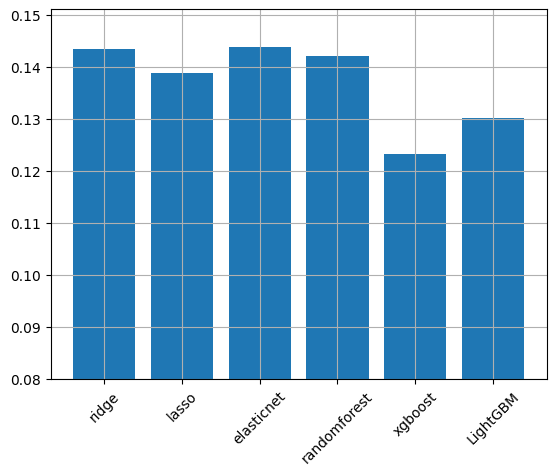

In [311]:
plt.bar(x=['ridge', 'lasso', 'elasticnet', 'randomforest', 'xgboost', 'LightGBM'], height= [rmse_ridge, rmse_lasso, rmse_elasticnet, rmse_rf, rmse_xgb, rmse_lgbm])
plt.ylim(0.08)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# According to this chart:
* Tree models performed better then linear models. That's because the data has a lot of non-linearity.
* The top three models are XGBoost, LightGBM, and RandomForest
# Instead of using only one model to predict our test_set, we will use a blend of these models.

# Finding the best weights for models

In [ ]:
import numpy as np

best_rmse = 999
best_weights = None

for xgb_w in np.arange(0.3, 0.7, 0.05):
    for lgbm_w in np.arange(0.1, 0.5, 0.05):
        lasso_w = round(1 - xgb_w - lgbm_w, 2)
        if lasso_w < 0 or lasso_w > 0.4:
            continue
        blend = xgb_w * xgb_preds + lgbm_w * lgbm_preds + lasso_w * lasso_preds
        rmse = root_mean_squared_error(y, blend)
        if rmse < best_rmse:
            best_rmse = rmse
            best_weights = (xgb_w, lgbm_w, lasso_w)

xgb_w, lgbm_w, lasso_w = best_weights
print(f'Best RMSE: {best_rmse:.4f}')
print(f'Best weights - XGB:{xgb_w:.2f} LGBM:{lgbm_w:.2f} Lasso:{lasso_w:.2f}')

Best RMSE: 0.1210
Best weights - XGB:0.60 LGBM:0.20 Lasso:0.20


# Making predictions on the test dataset

In [ ]:
xgb_pipeline = fit_a_model(xgb_model, tree_preprocessor, X, y)[0]
xgb_pipeline.fit(X, y)
xgb_test = xgb_pipeline.predict(X_test) # XGBoost's predictions for each house in test set

lgbm_pipeline = fit_a_model(lgbm_model, tree_preprocessor, X, y)[0]
lgbm_pipeline.fit(X,y)
lgbm_test = lgbm_pipeline.predict(X_test)  # LightGBM's predictions

lasso_pipeline = fit_a_model(lasso_model, linear_preprocessor, X, y)[0]
lasso_pipeline.fit(X, y)
lasso_test = lasso_pipeline.predict(X_test)  # Lasso's predictions

test_blend = xgb_w * xgb_test + lgbm_w * lgbm_test + lasso_w * lasso_test

submission = pd.DataFrame({
    'Id': submission_ids,
    'SalePrice': np.expm1(test_blend)
})
submission.to_csv('submission.csv') # saving the submission into a csv file

[LightGBM] [Info] Total Bins 3408
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 137
[LightGBM] [Info] Start training from score 12.021409
[LightGBM] [Info] Total Bins 3417
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 134
[LightGBM] [Info] Start training from score 12.023288
[LightGBM] [Info] Total Bins 3406
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 136
[LightGBM] [Info] Start training from score 12.020737
[LightGBM] [Info] Total Bins 3432
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 134
[LightGBM] [Info] Start training from score 12.032956
[LightGBM] [Info] Total Bins 3419
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 136
[LightGBM] [Info] Start training from score 12.021897
[LightGBM] [Info] Total Bins 3667
[LightGBM] [Info] Number of data points in the train set: 146

,Id,SalePrice
0,1461,122275.817762
1,1462,161809.470954
2,1463,180373.827196
3,1464,193257.803289
4,1465,194544.026936
...,...,...
1454,2915,83518.121601
1455,2916,84904.554300
1456,2917,154787.126531
1457,2918,118393.043431


# This got a score of 0.12158 on kaggle. 